
# Week 2: EDA and Data Quality Analysis

## Project
**Automated Casting Defect Detection Using Deep Learning and Computer Vision**

## Week 2 Objective
The aim of Week 2 is to understand the casting image dataset before model training.  
This notebook focuses on exploratory data analysis, image-quality checks, class distribution, duplicate checking, corrupted file checking and visual inspection.

## Team Contributions

| Member | Name | Role | Week 2 Contribution |
|---|---|---|---|
| Member 1 | Sandeep Bommagoni | Data & EDA Lead | Dataset loading, image inventory dataframe, class distribution and split count |
| Member 2 | Likith Kumar Devulapalli | Architecture / Xception Lead | Image-size analysis, channel analysis and sample-image visualisation |
| Member 3 | Raghava Krishna Battu | Model Comparison Lead | Corrupted image check and duplicate image hash analysis |
| Member 4 | Navatej Patel Cheerneni | Evaluation & XAI Lead | Average image analysis, pixel intensity distribution and EDA interpretation |
| Member 5 | Tharun Chinnachinnaiahgari | GitHub / Deployment Lead | Figure saving, README update, Week 2 summary and GitHub evidence organisation |



## 1. Import Libraries

**Contributor:** Tharun Chinnachinnaiahgari  
This section imports the libraries required for data exploration, image reading, visualisation and file checking.


In [7]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Import required libraries for Week 2 EDA

import os
import random
import hashlib
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")


Libraries imported successfully.



## 2. Dataset Path Configuration

**Contributor:** Sandeep Bommagoni  
This section defines the expected Kaggle dataset path and the two project classes.


In [8]:

# Contributor: Sandeep Bommagoni
# Task: Define dataset path and class folders

DATA_ROOT = Path("/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data")

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

CLASS_NAMES = ["def_front", "ok_front"]

print("Dataset root:", DATA_ROOT)
print("Train folder:", TRAIN_DIR)
print("Test folder:", TEST_DIR)
print("Class names:", CLASS_NAMES)

for folder in [DATA_ROOT, TRAIN_DIR, TEST_DIR]:
    print(folder, "exists:", folder.exists())


Dataset root: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data
Train folder: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train
Test folder: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test
Class names: ['def_front', 'ok_front']
/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data exists: True
/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train exists: True
/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test exists: True



## 3. Create Image Inventory DataFrame

**Contributor:** Sandeep Bommagoni  
This creates a structured table containing image path, split, label, filename and file extension.  
This inventory is the foundation for all EDA checks.


In [9]:

# Contributor: Sandeep Bommagoni
# Task: Create image inventory dataframe

def collect_image_records(root_dir, split_name):
    records = []
    root_dir = Path(root_dir)

    for label in CLASS_NAMES:
        label_dir = root_dir / label

        if not label_dir.exists():
            print(f"Warning: folder not found -> {label_dir}")
            continue

        for img_path in label_dir.glob("*"):
            if img_path.is_file():
                records.append({
                    "split": split_name,
                    "label": label,
                    "path": str(img_path),
                    "filename": img_path.name,
                    "extension": img_path.suffix.lower()
                })
    return records

records = []
records.extend(collect_image_records(TRAIN_DIR, "train"))
records.extend(collect_image_records(TEST_DIR, "test"))

df = pd.DataFrame(records)

print("Total image files found:", len(df))
display(df.head())


Total image files found: 7348


,split,label,path,filename,extension
0,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_6388.jpeg,.jpeg
1,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_3139.jpeg,.jpeg
2,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_3376.jpeg,.jpeg
3,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_9191.jpeg,.jpeg
4,train,def_front,/kaggle/input/real-life-industrial-dataset-of-...,cast_def_0_3431.jpeg,.jpeg



## 4. Class Distribution and Train/Test Split Count

**Contributor:** Sandeep Bommagoni  
This section checks how many images are available in each class and split.  
This is important because class imbalance may affect model training.


In [10]:

# Contributor: Sandeep Bommagoni
# Task: Analyse class distribution and split count

count_table = (
    df.groupby(["split", "label"])
      .size()
      .reset_index(name="image_count")
      .sort_values(["split", "label"])
)

display(count_table)

pivot_counts = count_table.pivot(index="label", columns="split", values="image_count").fillna(0).astype(int)
display(pivot_counts)

# Save result for GitHub evidence
Path("reports/model_results").mkdir(parents=True, exist_ok=True)
count_table.to_csv("reports/model_results/week2_class_distribution.csv", index=False)


,split,label,image_count
0,test,def_front,453
1,test,ok_front,262
2,train,def_front,3758
3,train,ok_front,2875


split,test,train
label,,
def_front,453,3758
ok_front,262,2875


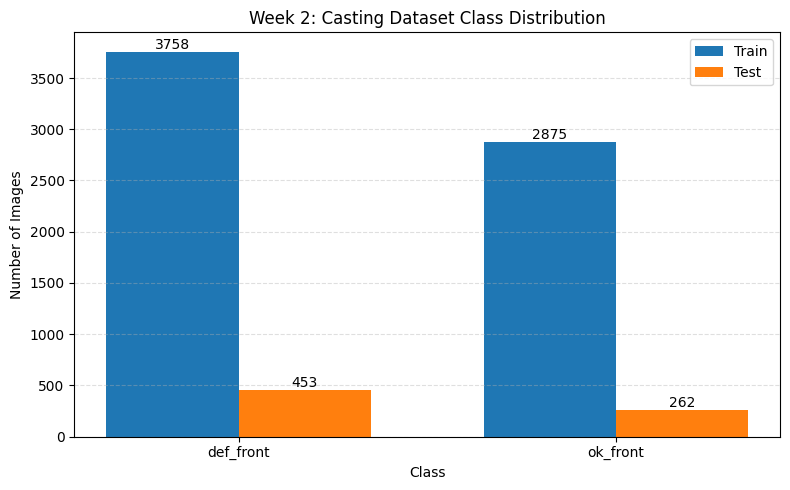

In [11]:

# Contributor: Sandeep Bommagoni
# Task: Create class distribution bar chart

if len(pivot_counts) > 0:
    labels = pivot_counts.index.tolist()
    x = np.arange(len(labels))
    width = 0.35

    train_values = pivot_counts["train"].values if "train" in pivot_counts.columns else np.zeros(len(labels))
    test_values = pivot_counts["test"].values if "test" in pivot_counts.columns else np.zeros(len(labels))

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, train_values, width, label="Train")
    bars2 = ax.bar(x + width/2, test_values, width, label="Test")

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                str(int(bar.get_height())),
                ha="center",
                va="bottom",
                fontsize=10
            )

    ax.set_title("Week 2: Casting Dataset Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Images")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    Path("reports/figures").mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig("reports/figures/week2_class_distribution.png", dpi=150)
    plt.show()
else:
    print("No data available for plotting.")



## 5. Image Readability, Size and Channel Analysis

**Contributor:** Likith Kumar Devulapalli  
This section checks whether images can be read, and records width, height and channel count.


In [12]:

# Contributor: Likith Kumar Devulapalli
# Task: Check image readability, dimensions and channels

def inspect_image(path):
    img = cv2.imread(path)
    if img is None:
        return pd.Series({
            "readable": False,
            "height": np.nan,
            "width": np.nan,
            "channels": np.nan
        })

    h, w = img.shape[:2]
    c = img.shape[2] if len(img.shape) == 3 else 1

    return pd.Series({
        "readable": True,
        "height": h,
        "width": w,
        "channels": c
    })

if len(df) > 0:
    image_meta = df["path"].apply(inspect_image)
    df = pd.concat([df, image_meta], axis=1)

    print("Unreadable / corrupted images:", (~df["readable"]).sum())
    display(df[["height", "width", "channels"]].describe())
    display(df.groupby(["split", "label", "readable"]).size().reset_index(name="count"))

    df.to_csv("reports/model_results/week2_image_inventory_with_metadata.csv", index=False)
else:
    print("No images found. Please check dataset path.")


Unreadable / corrupted images: 0


,height,width,channels
count,7348.0,7348.0,7348.0
mean,300.0,300.0,3.0
std,0.0,0.0,0.0
min,300.0,300.0,3.0
25%,300.0,300.0,3.0
50%,300.0,300.0,3.0
75%,300.0,300.0,3.0
max,300.0,300.0,3.0


,split,label,readable,count
0,test,def_front,True,453
1,test,ok_front,True,262
2,train,def_front,True,3758
3,train,ok_front,True,2875


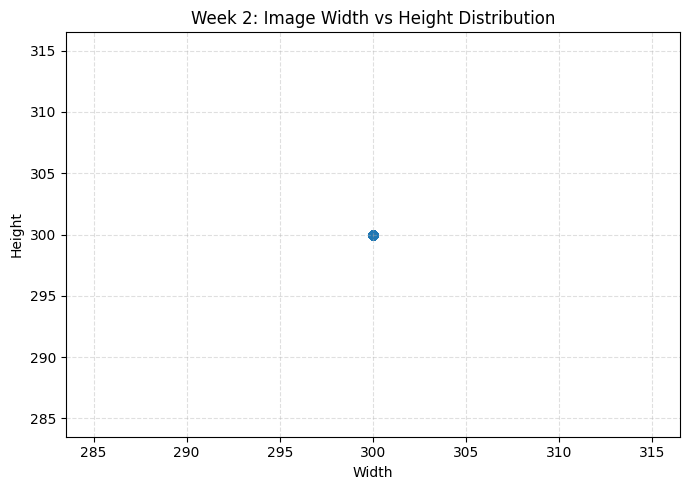

,width,height,count
0,300,300,7348


In [13]:

# Contributor: Likith Kumar Devulapalli
# Task: Plot image width and height distribution

if len(df) > 0 and "readable" in df.columns:
    valid_df = df[df["readable"]].copy()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(valid_df["width"], valid_df["height"], alpha=0.4)
    ax.set_title("Week 2: Image Width vs Height Distribution")
    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("reports/figures/week2_image_dimension_distribution.png", dpi=150)
    plt.show()

    dimension_counts = (
        valid_df.groupby(["width", "height"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(dimension_counts.head(10))
    dimension_counts.to_csv("reports/model_results/week2_dimension_counts.csv", index=False)
else:
    print("Image metadata not available.")



## 6. Random Sample Image Visualisation

**Contributor:** Likith Kumar Devulapalli  
This section visually compares defective and OK casting images.


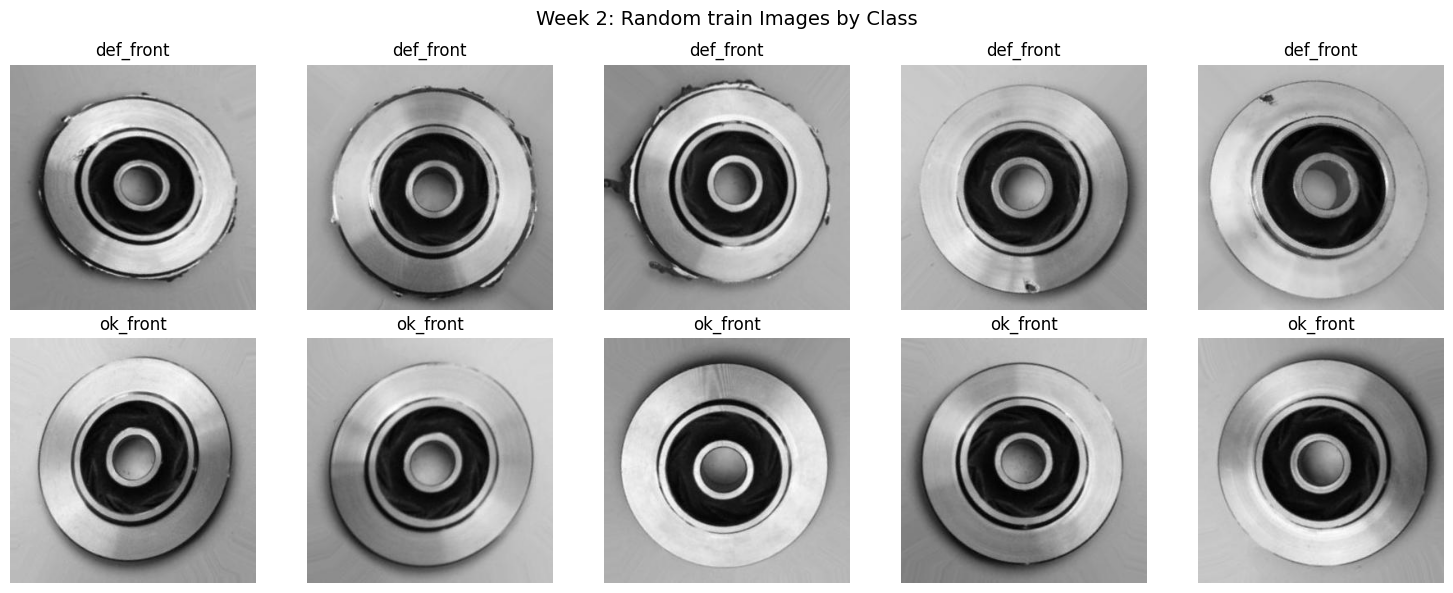

In [14]:

# Contributor: Likith Kumar Devulapalli
# Task: Display random sample images from each class

def show_random_samples(dataframe, split="train", samples_per_class=5):
    subset_df = dataframe[(dataframe["split"] == split) & (dataframe["readable"])]

    fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(samples_per_class * 3, 6))

    for row_idx, label in enumerate(CLASS_NAMES):
        subset = subset_df[subset_df["label"] == label]
        if len(subset) == 0:
            continue

        chosen = subset.sample(min(samples_per_class, len(subset)), random_state=SEED)

        for col_idx, (_, row) in enumerate(chosen.iterrows()):
            img = cv2.imread(row["path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis("off")
            axes[row_idx, col_idx].set_title(label)

    plt.suptitle(f"Week 2: Random {split} Images by Class", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"reports/figures/week2_random_{split}_samples.png", dpi=150)
    plt.show()

if len(df) > 0 and "readable" in df.columns:
    show_random_samples(df, split="train", samples_per_class=5)
else:
    print("No readable image data available.")



## 7. Corrupted Image Check

**Contributor:** Raghava Krishna Battu  
This section lists any unreadable files. These should be removed or excluded before training.


In [15]:

# Contributor: Raghava Krishna Battu
# Task: Identify corrupted or unreadable image files

if len(df) > 0 and "readable" in df.columns:
    corrupted_df = df[~df["readable"]].copy()
    print("Number of corrupted/unreadable images:", len(corrupted_df))
    display(corrupted_df)

    corrupted_df.to_csv("reports/model_results/week2_corrupted_images.csv", index=False)
else:
    print("Readable check not available.")


Number of corrupted/unreadable images: 0


,split,label,path,filename,extension,readable,height,width,channels



## 8. Duplicate Image Check Using MD5 Hash

**Contributor:** Raghava Krishna Battu  
Exact duplicates may cause data leakage if identical images appear in both train and test folders.  
This is important for critical evaluation.


In [16]:

# Contributor: Raghava Krishna Battu
# Task: Detect exact duplicate images using MD5 file hashing

def file_hash(path, block_size=65536):
    hasher = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            block = f.read(block_size)
            if not block:
                break
            hasher.update(block)
    return hasher.hexdigest()

if len(df) > 0 and "readable" in df.columns:
    valid_df = df[df["readable"]].copy()
    valid_df["md5_hash"] = valid_df["path"].apply(file_hash)

    duplicate_df = (
        valid_df.groupby("md5_hash")
        .filter(lambda x: len(x) > 1)
        .sort_values(["md5_hash", "split", "label"])
    )

    print("Duplicate file entries:", len(duplicate_df))
    print("Duplicate groups:", duplicate_df["md5_hash"].nunique())

    display(duplicate_df[["split", "label", "filename", "path", "md5_hash"]].head(30))

    duplicate_df.to_csv("reports/model_results/week2_duplicate_images.csv", index=False)
else:
    print("Duplicate check cannot run because image metadata is missing.")


Duplicate file entries: 128
Duplicate groups: 64


,split,label,filename,path,md5_hash
7194,test,ok_front,cast_ok_0_1022.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,033f2c3cd5e455eb823ad2c46d200437
4902,train,ok_front,cast_ok_0_1022.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,033f2c3cd5e455eb823ad2c46d200437
7190,test,ok_front,cast_ok_0_1095.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,05d1192be741dff53376c7b0df5d6c78
4881,train,ok_front,cast_ok_0_1095.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,05d1192be741dff53376c7b0df5d6c78
7288,test,ok_front,cast_ok_0_1173.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,06df33d7bd2257ae952f5af41f7be7ed
5946,train,ok_front,cast_ok_0_1173.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,06df33d7bd2257ae952f5af41f7be7ed
7327,test,ok_front,cast_ok_0_897.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,084250ff15695c700303993b8540c084
6375,train,ok_front,cast_ok_0_897.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,084250ff15695c700303993b8540c084
7208,test,ok_front,cast_ok_0_1171.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,0ed8b2ddda0187e6bc96459678326b76
5051,train,ok_front,cast_ok_0_1171.jpeg,/kaggle/input/real-life-industrial-dataset-of-...,0ed8b2ddda0187e6bc96459678326b76



## 9. Average Image by Class

**Contributor:** Navatej Patel Cheerneni  
Average images help us visually understand whether there are broad appearance differences between defective and OK classes.


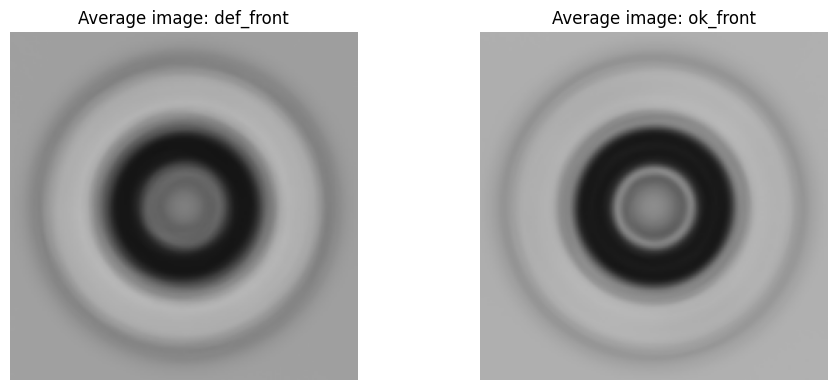

In [17]:

# Contributor: Navatej Patel Cheerneni
# Task: Generate average image for each class

def average_image_for_label(dataframe, label, split="train", image_size=(224, 224), max_images=500):
    subset = dataframe[
        (dataframe["split"] == split) &
        (dataframe["label"] == label) &
        (dataframe["readable"])
    ].copy()

    if len(subset) == 0:
        return None

    subset = subset.sample(min(max_images, len(subset)), random_state=SEED)

    accumulator = np.zeros((image_size[0], image_size[1], 3), dtype=np.float64)
    count = 0

    for path in subset["path"]:
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)
        accumulator += img
        count += 1

    if count == 0:
        return None

    return (accumulator / count).astype(np.uint8)

if len(df) > 0 and "readable" in df.columns:
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(10, 4))

    for i, label in enumerate(CLASS_NAMES):
        avg_img = average_image_for_label(df, label)
        if avg_img is not None:
            axes[i].imshow(avg_img)
        axes[i].axis("off")
        axes[i].set_title(f"Average image: {label}")

    plt.tight_layout()
    plt.savefig("reports/figures/week2_average_images_by_class.png", dpi=150)
    plt.show()
else:
    print("Average image cannot be generated.")



## 10. Pixel Intensity Distribution

**Contributor:** Navatej Patel Cheerneni  
Pixel intensity analysis helps compare the visual characteristics of defective and OK images.


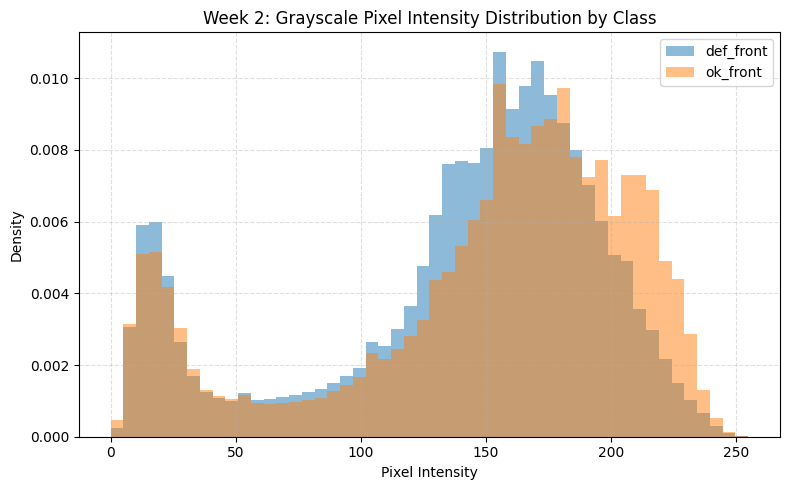

In [18]:

# Contributor: Navatej Patel Cheerneni
# Task: Compare grayscale pixel intensity distribution by class

def collect_pixel_intensities(dataframe, label, split="train", max_images=300, image_size=(128, 128)):
    subset = dataframe[
        (dataframe["split"] == split) &
        (dataframe["label"] == label) &
        (dataframe["readable"])
    ].copy()

    if len(subset) == 0:
        return np.array([])

    subset = subset.sample(min(max_images, len(subset)), random_state=SEED)
    values = []

    for path in subset["path"]:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, image_size)
        values.extend(img.flatten())

    return np.array(values)

if len(df) > 0 and "readable" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))

    for label in CLASS_NAMES:
        pixels = collect_pixel_intensities(df, label)
        if len(pixels) > 0:
            ax.hist(pixels, bins=50, alpha=0.5, density=True, label=label)

    ax.set_title("Week 2: Grayscale Pixel Intensity Distribution by Class")
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("reports/figures/week2_pixel_intensity_distribution.png", dpi=150)
    plt.show()
else:
    print("Pixel intensity analysis cannot be generated.")



## 11. Week 2 EDA Findings

**Contributor:** Navatej Patel Cheerneni and Tharun Chinnachinnaiahgari

### Key Findings to Report
After running this notebook, update the points below with actual values:

1. Total number of images found.
2. Number of defective and OK images in train and test folders.
3. Whether class imbalance exists.
4. Whether unreadable/corrupted images exist.
5. Whether duplicate image groups exist.
6. Whether image dimensions are consistent.
7. Whether visual inspection suggests clear differences between classes.
8. Whether any dataset limitation may affect model generalisation.

### Critical Note
If duplicate images are found, they must be mentioned in the final report as a possible data leakage risk, especially if duplicates occur across train and test folders.


In [20]:
# Contributor: Tharun Chinnachinnaiahgari
# Task: Save Week 2 EDA summary values for documentation

from pathlib import Path
import json

summary = {}

if len(df) > 0:
    summary["total_images"] = int(len(df))

    # Convert tuple keys into readable string keys for JSON
    class_counts = (
        df.groupby(["split", "label"])
        .size()
        .reset_index(name="count")
    )

    summary["class_counts"] = {
        f"{row['split']}_{row['label']}": int(row["count"])
        for _, row in class_counts.iterrows()
    }

    if "readable" in df.columns:
        summary["corrupted_images"] = int((~df["readable"]).sum())

    if "valid_df" in globals() and "md5_hash" in valid_df.columns:
        duplicate_rows = valid_df.groupby("md5_hash").filter(lambda x: len(x) > 1)

        summary["duplicate_file_entries"] = int(duplicate_rows.shape[0])
        summary["duplicate_groups"] = int(duplicate_rows["md5_hash"].nunique())

    # Optional useful extra values
    if "height" in df.columns and "width" in df.columns:
        readable_df = df[df["readable"]].copy()
        summary["unique_image_dimensions"] = int(
            readable_df[["width", "height"]].drop_duplicates().shape[0]
        )

summary_path = Path("reports/model_results/week2_eda_summary.json")
summary_path.parent.mkdir(parents=True, exist_ok=True)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Week 2 EDA summary saved to:", summary_path)
print(summary)

Week 2 EDA summary saved to: reports/model_results/week2_eda_summary.json
{'total_images': 7348, 'class_counts': {'test_def_front': 453, 'test_ok_front': 262, 'train_def_front': 3758, 'train_ok_front': 2875}, 'corrupted_images': 0, 'duplicate_file_entries': 128, 'duplicate_groups': 64, 'unique_image_dimensions': 1}
